In [1]:
from util import *
from rich import print as rprint
plt.rcParams['font.family'] = 'Noto Sans'

%reload_ext autoreload
%autoreload 2

In [2]:
figPath = "../plots/control_designs/"

dirs = [a for a in getDirs(os.path.join(dataPath, 'control'), sstr='nVDCC') if "ISI_20" in a]
dirs.sort(key=natural_keys)
control_dirs = np.array(dirs)

## Get a list of designs in each category 
designs_in_categories = get_designs_in_categories(control_dirs)

for i,d in enumerate(control_dirs): print(i, d)

0 nVDCC_1_dVAZ_60_nAZ_33_RRP_55_ISI_20_nAP_10
1 nVDCC_1_dVAZ_60_nAZ_33_RRP_60_ISI_20_nAP_10
2 nVDCC_2_dVAZ_60_nAZ_7_RRP_60_ISI_20_nAP_10
3 nVDCC_2_dVAZ_60_nAZ_9_RRP_55_ISI_20_nAP_10
4 nVDCC_2_dVAZ_60_nAZ_9_RRP_60_ISI_20_nAP_10
5 nVDCC_2_dVAZ_60_nAZ_11_RRP_40_ISI_20_nAP_10
6 nVDCC_2_dVAZ_60_nAZ_11_RRP_45_ISI_20_nAP_10
7 nVDCC_2_dVAZ_60_nAZ_11_RRP_50_ISI_20_nAP_10
8 nVDCC_2_dVAZ_60_nAZ_13_RRP_35_ISI_20_nAP_10
9 nVDCC_2_dVAZ_60_nAZ_13_RRP_40_ISI_20_nAP_10
10 nVDCC_2_dVAZ_60_nAZ_13_RRP_45_ISI_20_nAP_10
11 nVDCC_2_dVAZ_60_nAZ_13_RRP_50_ISI_20_nAP_10
12 nVDCC_2_dVAZ_60_nAZ_15_RRP_30_ISI_20_nAP_10
13 nVDCC_2_dVAZ_60_nAZ_15_RRP_35_ISI_20_nAP_10
14 nVDCC_2_dVAZ_60_nAZ_17_RRP_30_ISI_20_nAP_10
15 nVDCC_2_dVAZ_60_nAZ_19_RRP_30_ISI_20_nAP_10
16 nVDCC_2_dVAZ_60_nAZ_21_RRP_20_ISI_20_nAP_10
17 nVDCC_2_dVAZ_60_nAZ_21_RRP_25_ISI_20_nAP_10
18 nVDCC_2_dVAZ_60_nAZ_23_RRP_20_ISI_20_nAP_10
19 nVDCC_2_dVAZ_60_nAZ_23_RRP_25_ISI_20_nAP_10
20 nVDCC_2_dVAZ_60_nAZ_25_RRP_20_ISI_20_nAP_10
21 nVDCC_2_dVAZ_60_nAZ_27_

### Load category info
Create category_info.pk file if it doesn't exist. Update it if needed

In [3]:
## If True, recreate category_info.pk. Override if category_info exists.
override = False

category_info_path = os.path.join(dataPath, 'control_eachCa/category_info.pk')
if os.path.exists(category_info_path) and not override:
    with open(category_info_path, "rb") as infile:
        category_info = pk.load(infile)
        
else:
    # get info (Pr, nRel, MVU, facilitation, Ca peak, residual Ca, syt) of each category
    category_info = np.empty([3,3,3,3], dtype=object)
    for nv, dv, naz, rrp in tq(list(product(range(3), repeat=4))):
        category_info[nv, dv, naz, rrp] = {'n_designs': len(designs_in_categories[nv, dv, naz, rrp])}

        # get representative designs (max and median facilitation)
        category_info[nv, dv, naz, rrp].update(get_rep_design(designs_in_categories[nv, dv, naz, rrp]))

        # Info related to vesicle release
        category_info[nv, dv, naz, rrp].update(get_release_info(designs_in_categories[nv, dv, naz, rrp]))

        # Calcium info
        category_info[nv, dv, naz, rrp].update(get_calcium_info(designs_in_categories[nv, dv, naz, rrp]))

        # Info about synaptotagmin
        category_info[nv, dv, naz, rrp].update(get_synaptotagmin_info(designs_in_categories[nv, dv, naz, rrp]))

        # Info about calcium overlap
        category_info[nv, dv, naz, rrp].update(get_ca_overlap_info(designs_in_categories[nv, dv, naz, rrp]))

    with open(category_info_path, "wb") as infile:
        pk.dump(category_info, infile)
    
    print(category_info[0,0,0,0].keys(), '\n\n', category_info[0,0,0,0])

## If True, update category_info.pk with new design info
update = False
if update:
    for nv, dv, naz, rrp in tq(list(product(range(3), repeat=4))):
        if len(designs_in_categories[nv, dv, naz, rrp]) >= 4:
            ...
            # Info about synaptotagmin
            # category_info[nv, dv, naz, rrp].update(get_synaptotagmin_info(designs_in_categories[nv, dv, naz, rrp]))

    with open(category_info_path, "wb") as infile:
        pk.dump(category_info, infile)

    print(category_info[0,0,0,0])
    print(category_info[2,2,2,1])

In [4]:
rprint(category_info[1,2,2,2])

{
    'n_designs': 34,
    'rep_design_max': np.str_('nVDCC_6_dVAZ_200_nAZ_35_RRP_50_ISI_20_nAP_10'),
    'rep_design_median': np.str_('nVDCC_6_dVAZ_200_nAZ_29_RRP_50_ISI_20_nAP_10'),
    'pr': (
        array([0.24797353, 0.61528824, 0.83561471, 0.93785882, 0.97483529,
       0.99003529, 0.99605   , 0.9981    , 0.99926471, 0.99952941]),
        array([0.02353632, 0.03718776, 0.03120082, 0.01861853, 0.00992442,
       0.00514318, 0.00260444, 0.0018031 , 0.00070955, 0.00054153])
    ),
    'rel': (
        array([0.28600882, 0.95198235, 1.81274412, 2.74143529, 3.68284118,
       4.60148235, 5.46346765, 6.30729706, 7.11386176, 7.89974706]),
        array([0.03224273, 0.10095943, 0.1770981 , 0.28186012, 0.37689018,
       0.48666174, 0.57055538, 0.70274575, 0.81319501, 0.90435444])
    ),
    'mvu': (
        array([1.151526  , 1.5430953 , 2.16464778, 2.9184905 , 3.77467688,
       4.64570799, 5.48404768, 6.31836711, 7.11872188, 7.90317516]),
        array([0.02564424, 0.07327315, 0.13547502, 0.24620164, 0.35291002,
       0.47140241, 0.56243144, 0.69586031, 0.81065964, 0.90234378])
    ),
    'facil': (
        array([1.        , 1.33956826, 1.87870983, 2.53202257, 3.27417399,
       4.02898093, 4.75621421, 5.47888093, 6.17253737, 6.8528875 ]),
        array([5.38537270e-17, 4.29486653e-02, 8.88297978e-02, 1.73503969e-01,
       2.51771745e-01, 3.38739654e-01, 4.09304410e-01, 5.09692047e-01,
       5.97171603e-01, 6.67438582e-01])
    ),
    'avg_ca_peak': (
        array([3.17997239, 3.30750261, 3.40259018, 3.48468683, 3.54540392,
       3.59508064, 3.63694705, 3.69455701, 3.72539654, 3.76752666]),
        array([0.18664346, 0.19041164, 0.19777544, 0.20855615, 0.21120641,
       0.20880977, 0.2144509 , 0.21926228, 0.21315793, 0.20239702])
    ),
    'avg_res_ca': (
        array([0.13956143, 0.17288323, 0.20157433, 0.22600633, 0.24771031,
       0.26808156, 0.28705863, 0.30558138, 0.32309403, 0.33970973]),
        array([0.00177894, 0.00302357, 0.00473771, 0.00589089, 0.00732196,
       0.00849476, 0.00921923, 0.01090728, 0.01202412, 0.01360223])
    ),
    'avg_ca_syt7_peak': (
        array([0.00732093, 0.02214783, 0.03545371, 0.04709957, 0.05715465,
       0.0656356 , 0.07282529, 0.07906637, 0.08440964, 0.08904802]),
        array([0.00036188, 0.00075692, 0.00110245, 0.00144013, 0.00174778,
       0.00198055, 0.00220465, 0.00238072, 0.0025191 , 0.00262214])
    ),
    'avg_ca_syt1_peak': (
        array([0.03886815, 0.04207752, 0.04457972, 0.04670547, 0.04836428,
       0.04992221, 0.05112798, 0.05252485, 0.05349708, 0.05453338]),
        array([0.00239927, 0.00268965, 0.00280492, 0.00307668, 0.00317496,
       0.00309405, 0.00320863, 0.00337388, 0.0033516 , 0.00321472])
    ),
    'rep_design_min': np.str_('nVDCC_6_dVAZ_200_nAZ_27_RRP_45_ISI_20_nAP_10'),
    'avg_peak_overlap': (
        array([0.46118472, 0.46805573, 0.47442805, 0.47780897, 0.48219835,
       0.48616766, 0.48900134, 0.49379153, 0.49290034, 0.49882205]),
        array([0.04474495, 0.04340579, 0.04454305, 0.04249971, 0.04257542,
       0.04155873, 0.04095738, 0.04213792, 0.03926819, 0.04021916])
    ),
    'avg_basal_overlap': (
        array([0.1866885 , 0.28194977, 0.34271708, 0.38617206, 0.41915504,
       0.44491147, 0.46552976, 0.48361856, 0.49967303, 0.51326392]),
        array([0.00702177, 0.00785694, 0.00821492, 0.0095692 , 0.00967865,
       0.00945742, 0.00991329, 0.01023443, 0.01046466, 0.01070123])
    )
}

## Plot
- Pr
- nRel
- mvu
- Facilitation

In [5]:
for k in list(category_info[0,0,0,0]): print(k)

n_designs
rep_design_max
rep_design_median
pr
rel
mvu
facil
avg_ca_peak
avg_res_ca
avg_ca_syt7_peak
avg_ca_syt1_peak
rep_design_min
avg_peak_overlap
avg_basal_overlap


In [7]:
figsize_4d = (5,4.1)

ticklabelsize_4d = 8
labelsize_4d = 10
sublabelsize_4d = 8
textsize_4d = 8

cases = ['Low', 'Mid', 'High']


### Pr

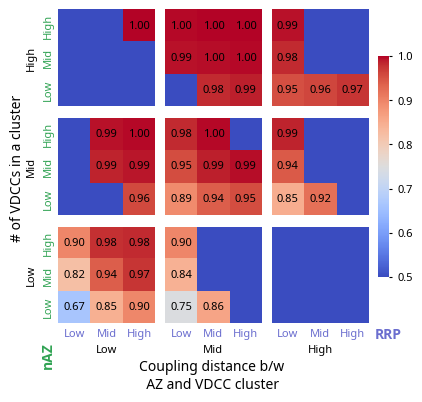

In [ ]:
key = 'pr'
cat_plot = np.zeros(category_info.shape)
for nv, dv, naz, rrp in product(range(3), repeat=4):
    try:
        cat_plot[nv, dv, naz, rrp] = category_info[nv, dv, naz, rrp][key][0][-1]
    except KeyError:
        cat_plot[nv, dv, naz, rrp] = 0

fig, ax = plt.subplots(3, 3, sharex=True, sharey=True, figsize=figsize_4d)
fig.subplots_adjust(wspace=0.1, hspace=0.1)

for axis in ax[-1,:]:
    axis.set_xticks(range(3))
    axis.set_xticklabels(cases, color=cpdark[5], fontsize=ticklabelsize_4d)

for axis in ax[:,0]:
    axis.set_yticks(range(3))
    axis.set_yticklabels(cases, color=cpdark[2], fontsize=ticklabelsize_4d,
                         rotation=90, ha="right", va="center")

for nv, dv in product(range(3), range(3)):
    ax[nv][dv].tick_params(axis=u'both', which=u'both',length=0)
    
    imdata = cat_plot[dv, 2-nv]
    im = ax[nv][dv].imshow(
        imdata, 
        vmin=0.5, 
        vmax=1.0, 
        cmap='coolwarm', 
        origin='lower'
    )
    
    for i in range(3):
        for j in range(3):
            if imdata[i, j] > 0.001:
                text = ax[nv][dv].text(j, i, f'{imdata[i, j]:0.2f}', fontsize=textsize_4d,
                                       ha="center", va="center", color="black")
    if nv==2:
        ax[nv][dv].set_xlabel(cases[dv], fontsize=sublabelsize_4d)
    if dv==0:
        ax[nv][dv].set_ylabel(cases[2-nv], fontsize=sublabelsize_4d)
       
    ax[nv][dv].spines[["bottom","top","right","left"]].set_visible(False)
    
ax[-1,0].text(-1.05, -1.8, 'nAZ', size=labelsize_4d, rotation=90, color=cpdark[2], fontweight='bold')
ax[-1,-1].text(2.7, -0.96, 'RRP', size=labelsize_4d, color=cpdark[5], fontweight='bold')
ax[-1,1].text(-1.3, -2.5, 'coupling distance b/w\n  AZ and VDCC cluster', size=labelsize_4d, color=cpdark[-1])
ax[1,0].text(-2, -1.2, '# of VDCCs in a cluster', size=labelsize_4d, rotation=90, color=cpdark[-1])

cb = fig.colorbar(im, ax=ax.ravel().tolist(), shrink=0.7, anchor=(-0.2,0.5))
cb.outline.set_visible(False)
cb.ax.tick_params(size=2, labelsize=ticklabelsize_4d)
plt.show()

fig.savefig(os.path.join(figPath, f'{key}_4D.pdf'), dpi=300, 
            bbox_inches='tight', transparent=True)

In [ ]:
key = 'pr'
fig, ax = plt.subplots(9,9, figsize=(13,10), sharex=True, sharey=True)
fig.subplots_adjust(wspace=0, hspace=0)

x = list(range(1,11))
for nv, dv, naz, rrp in list(product(range(3), repeat=4))[:]:
    try:
        design_y, design_std = category_info[nv, dv, naz, rrp][key]
    except KeyError:
        continue

    row = 3*(2 - dv) + (2 - naz)
    col = 3*nv + rrp
    # print(row, col)

    ax[row, col].plot(x, design_y, '.-')
    # ax[row, col].fill_between(x, design_y - design_std, design_y + design_std, alpha=0.2)

    # for axis in ax.ravel():
    #     axis.tick_params(left=False, right=False, labelleft=False,
    #                      labelbottom=False, bottom=False)
    #     axis.set_ylim(0, 1.05)
plt.show()

# fig.savefig(os.path.join(figPath, f'{key}_4D_full.pdf'), dpi=300, 
#           bbox_inches='tight', transparent=True) 

### Vesicle Releases

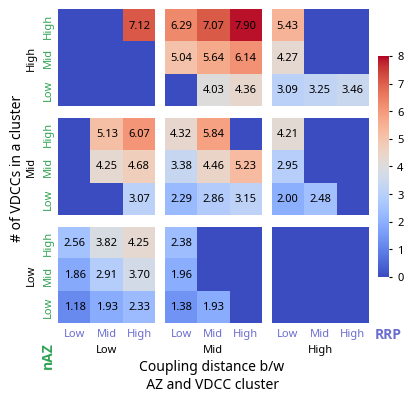

In [ ]:
key = 'rel'
cat_plot = np.zeros(category_info.shape)
for nv, dv, naz, rrp in product(range(3), repeat=4):
    try:
        cat_plot[nv, dv, naz, rrp] = category_info[nv, dv, naz, rrp][key][0][-1]
    except KeyError:
        cat_plot[nv, dv, naz, rrp] = 0

fig, ax = plt.subplots(3, 3, sharex=True, sharey=True, figsize=figsize_4d)
fig.subplots_adjust(wspace=0.1, hspace=0.1)

for axis in ax[-1,:]:
    axis.set_xticks(range(3))
    axis.set_xticklabels(cases, color=cpdark[5], fontsize=ticklabelsize_4d)

for axis in ax[:,0]:
    axis.set_yticks(range(3))
    axis.set_yticklabels(cases, color=cpdark[2], fontsize=ticklabelsize_4d,
                         rotation=90, ha="right", va="center")

for nv, dv in product(range(3), range(3)):
    ax[nv][dv].tick_params(axis=u'both', which=u'both',length=0)
    
    imdata = cat_plot[dv, 2-nv]
    im = ax[nv][dv].imshow(
        imdata,
        vmin=np.floor(np.min(cat_plot)) if np.min(cat_plot)>1 else np.min(cat_plot), 
        vmax=np.ceil(np.max(cat_plot)) if np.max(cat_plot)>1 else np.max(cat_plot),
        cmap='coolwarm', 
        origin='lower'
    )
    
    for i in range(3):
        for j in range(3):
            if imdata[i, j] > 0.001:
                text = ax[nv][dv].text(j, i, f'{imdata[i, j]:0.2f}', fontsize=textsize_4d,
                                       ha="center", va="center", color="black")
    if nv==2:
        ax[nv][dv].set_xlabel(cases[dv], fontsize=sublabelsize_4d)
    if dv==0:
        ax[nv][dv].set_ylabel(cases[2-nv], fontsize=sublabelsize_4d)
       
    ax[nv][dv].spines[["bottom","top","right","left"]].set_visible(False)
    
ax[-1,0].text(-1.05, -1.8, 'nAZ', size=labelsize_4d, rotation=90, color=cpdark[2], fontweight='bold')
ax[-1,-1].text(2.7, -0.96, 'RRP', size=labelsize_4d, color=cpdark[5], fontweight='bold')
ax[-1,1].text(-1.3, -2.5, 'coupling distance b/w\n  AZ and VDCC cluster', size=labelsize_4d, color=cpdark[-1])
ax[1,0].text(-2, -1.2, '# of VDCCs in a cluster', size=labelsize_4d, rotation=90, color=cpdark[-1])

cb = fig.colorbar(im, ax=ax.ravel().tolist(), shrink=0.7, anchor=(-0.2,0.5))
cb.outline.set_visible(False)
cb.ax.tick_params(size=2, labelsize=ticklabelsize_4d)
plt.show()

fig.savefig(os.path.join(figPath, f'{key}_4D.pdf'), dpi=300, 
            bbox_inches='tight', transparent=True)

In [ ]:
key = 'rel'
fig, ax = plt.subplots(9,9, figsize=(13,10), sharex=True, sharey=True)
fig.subplots_adjust(wspace=0, hspace=0)

x = list(range(1,11))
for nv, dv, naz, rrp in list(product(range(3), repeat=4))[:]:
    try:
        design_y, design_std = category_info[nv, dv, naz, rrp][key]
    except KeyError:
        continue

    row = 3*(2 - nv) + (2 - naz)
    col = 3*dv + rrp
    # print(row, col)

    ax[row, col].plot(x, design_y, '.-')
    ax[row, col].fill_between(x, design_y - design_std, design_y + design_std, alpha=0.2)

    for axis in ax.ravel():
        axis.tick_params(left=False, right=False, labelleft=False,
                         labelbottom=False, bottom=False)
        # axis.set_ylim(0, 1.1)

# fig.savefig(os.path.join(figPath, f'{key}_4D_full.pdf'), dpi=300, 
#           bbox_inches='tight', transparent=True) 

### Multi-vesicle usage

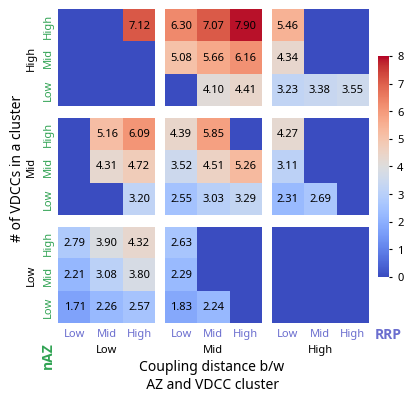

In [ ]:
key = 'mvu'
cat_plot = np.zeros(category_info.shape)
for nv, dv, naz, rrp in product(range(3), repeat=4):
    try:
        cat_plot[nv, dv, naz, rrp] = category_info[nv, dv, naz, rrp][key][0][-1]
    except KeyError:
        cat_plot[nv, dv, naz, rrp] = 0

fig, ax = plt.subplots(3, 3, sharex=True, sharey=True, figsize=figsize_4d)
fig.subplots_adjust(wspace=0.1, hspace=0.1)

for axis in ax[-1,:]:
    axis.set_xticks(range(3))
    axis.set_xticklabels(cases, color=cpdark[5], fontsize=ticklabelsize_4d)

for axis in ax[:,0]:
    axis.set_yticks(range(3))
    axis.set_yticklabels(cases, color=cpdark[2], fontsize=ticklabelsize_4d,
                         rotation=90, ha="right", va="center")

for nv, dv in product(range(3), range(3)):
    ax[nv][dv].tick_params(axis=u'both', which=u'both',length=0)
    
    imdata = cat_plot[dv, 2-nv]
    im = ax[nv][dv].imshow(
        imdata,
        vmin=np.floor(np.min(cat_plot)) if np.min(cat_plot)>1 else np.min(cat_plot), 
        vmax=np.ceil(np.max(cat_plot)) if np.max(cat_plot)>1 else np.max(cat_plot),
        cmap='coolwarm', 
        origin='lower'
    )
    
    for i in range(3):
        for j in range(3):
            if imdata[i, j] > 0.001:
                text = ax[nv][dv].text(j, i, f'{imdata[i, j]:0.2f}', fontsize=textsize_4d,
                                       ha="center", va="center", color="black")
    if nv==2:
        ax[nv][dv].set_xlabel(cases[dv], fontsize=sublabelsize_4d)
    if dv==0:
        ax[nv][dv].set_ylabel(cases[2-nv], fontsize=sublabelsize_4d)
       
    ax[nv][dv].spines[["bottom","top","right","left"]].set_visible(False)
    
ax[-1,0].text(-1.05, -1.8, 'nAZ', size=labelsize_4d, rotation=90, color=cpdark[2], fontweight='bold')
ax[-1,-1].text(2.7, -0.96, 'RRP', size=labelsize_4d, color=cpdark[5], fontweight='bold')
ax[-1,1].text(-1.3, -2.5, 'coupling distance b/w\n  AZ and VDCC cluster', size=labelsize_4d, color=cpdark[-1])
ax[1,0].text(-2, -1.2, '# of VDCCs in a cluster', size=labelsize_4d, rotation=90, color=cpdark[-1])

cb = fig.colorbar(im, ax=ax.ravel().tolist(), shrink=0.7, anchor=(-0.2,0.5))
cb.outline.set_visible(False)
cb.ax.tick_params(size=2, labelsize=ticklabelsize_4d)
plt.show()

fig.savefig(os.path.join(figPath, f'{key}_4D.pdf'), dpi=300, 
            bbox_inches='tight', transparent=True)

In [ ]:
key = 'mvu'
fig, ax = plt.subplots(9,9, figsize=(13,10), sharex=True, sharey=True)
fig.subplots_adjust(wspace=0, hspace=0)

x = list(range(1,11))
for nv, dv, naz, rrp in list(product(range(3), repeat=4))[:]:
    try:
        design_y, design_std = category_info[nv, dv, naz, rrp][key]
    except KeyError:
        continue

    row = 3*(2 - nv) + (2 - naz)
    col = 3*dv + rrp
    # print(row, col)

    ax[row, col].plot(x, design_y, '.-')
    ax[row, col].fill_between(x, design_y - design_std, design_y + design_std, alpha=0.2)

    for axis in ax.ravel():
        axis.tick_params(left=False, right=False, labelleft=False,
                         labelbottom=False, bottom=False)
        # axis.set_ylim(0, 1.1)

plt.show()
# fig.savefig(os.path.join(figPath, f'{key}_4D_full.pdf'), dpi=300, 
#           bbox_inches='tight', transparent=True) 

### Facilitation

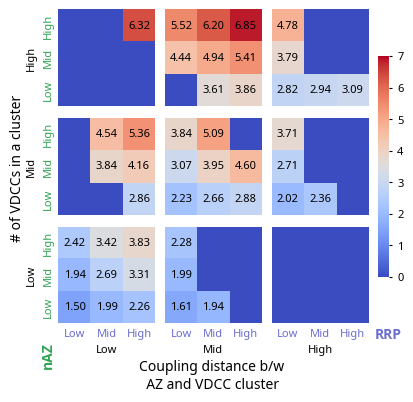

In [ ]:
key = 'facil'
cat_plot = np.zeros(category_info.shape)
for nv, dv, naz, rrp in product(range(3), repeat=4):
    try:
        cat_plot[nv, dv, naz, rrp] = category_info[nv, dv, naz, rrp][key][0][-1]
    except KeyError:
        cat_plot[nv, dv, naz, rrp] = 0

fig, ax = plt.subplots(3, 3, sharex=True, sharey=True, figsize=figsize_4d)
fig.subplots_adjust(wspace=0.1, hspace=0.1)

for axis in ax[-1,:]:
    axis.set_xticks(range(3))
    axis.set_xticklabels(cases, color=cpdark[5], fontsize=ticklabelsize_4d)

for axis in ax[:,0]:
    axis.set_yticks(range(3))
    axis.set_yticklabels(cases, color=cpdark[2], fontsize=ticklabelsize_4d,
                         rotation=90, ha="right", va="center")

for nv, dv in product(range(3), range(3)):
    ax[nv][dv].tick_params(axis=u'both', which=u'both',length=0)
    
    imdata = cat_plot[dv, 2-nv]
    im = ax[nv][dv].imshow(
        imdata,
        vmin=np.floor(np.min(cat_plot)) if np.min(cat_plot)>1 else np.min(cat_plot), 
        vmax=np.ceil(np.max(cat_plot)) if np.max(cat_plot)>1 else np.max(cat_plot),
        cmap='coolwarm', 
        origin='lower'
    )
    
    for i in range(3):
        for j in range(3):
            if imdata[i, j] > 0.001:
                text = ax[nv][dv].text(j, i, f'{imdata[i, j]:0.2f}', fontsize=textsize_4d,
                                       ha="center", va="center", color="black")
    if nv==2:
        ax[nv][dv].set_xlabel(cases[dv], fontsize=sublabelsize_4d)
    if dv==0:
        ax[nv][dv].set_ylabel(cases[2-nv], fontsize=sublabelsize_4d)
       
    ax[nv][dv].spines[["bottom","top","right","left"]].set_visible(False)
    
ax[-1,0].text(-1.05, -1.8, 'nAZ', size=labelsize_4d, rotation=90, color=cpdark[2], fontweight='bold')
ax[-1,-1].text(2.7, -0.96, 'RRP', size=labelsize_4d, color=cpdark[5], fontweight='bold')
ax[-1,1].text(-1.3, -2.5, 'coupling distance b/w\n  AZ and VDCC cluster', size=labelsize_4d, color=cpdark[-1])
ax[1,0].text(-2, -1.2, '# of VDCCs in a cluster', size=labelsize_4d, rotation=90, color=cpdark[-1])

cb = fig.colorbar(im, ax=ax.ravel().tolist(), shrink=0.7, anchor=(-0.2,0.5))
cb.outline.set_visible(False)
cb.ax.tick_params(size=2, labelsize=ticklabelsize_4d)
plt.show()

fig.savefig(os.path.join(figPath, f'{key}_4D.pdf'), dpi=300, 
            bbox_inches='tight', transparent=True)

In [ ]:
key = 'facil'
fig, ax = plt.subplots(9,9, figsize=(13,10), sharex=True, sharey=True)
fig.subplots_adjust(wspace=0, hspace=0)

x = list(range(1,11))
for nv, dv, naz, rrp in list(product(range(3), repeat=4))[:]:
    try:
        design_y, design_std = category_info[nv, dv, naz, rrp][key]
    except KeyError:
        continue

    row = 3*(2 - nv) + (2 - naz)
    col = 3*dv + rrp
    # print(row, col)

    ax[row, col].plot(x, design_y, '.-')
    ax[row, col].fill_between(x, design_y - design_std, design_y + design_std, alpha=0.2)

    for axis in ax.ravel():
        axis.tick_params(left=False, right=False, labelleft=False,
                         labelbottom=False, bottom=False)
        # axis.set_ylim(0, 1.1)

# fig.savefig(os.path.join(figPath, f'{key}_4D_full.pdf'), dpi=300, 
#           bbox_inches='tight', transparent=True) 

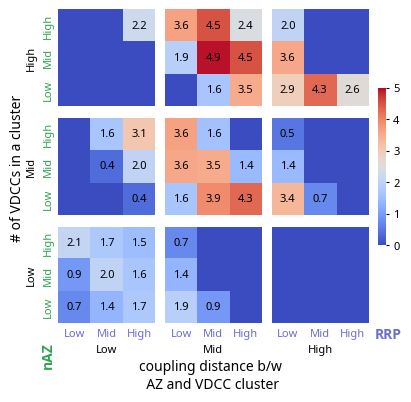

In [41]:
key = 'n_designs'
cat_plot = np.zeros(category_info.shape)
for nv, dv, naz, rrp in product(range(3), repeat=4):
    try:
        cat_plot[nv, dv, naz, rrp] = category_info[nv, dv, naz, rrp][key]
    except KeyError:
        cat_plot[nv, dv, naz, rrp] = 0

tot_designs = np.sum(cat_plot)
min_val = np.min(cat_plot*100.0/tot_designs)
max_val = np.max(cat_plot*100.0/tot_designs)

fig, ax = plt.subplots(3, 3, sharex=True, sharey=True, figsize=figsize_4d)
fig.subplots_adjust(wspace=0.1, hspace=0.1)

for axis in ax[-1,:]:
    axis.set_xticks(range(3))
    axis.set_xticklabels(cases, color=cpdark[5], fontsize=ticklabelsize_4d)

for axis in ax[:,0]:
    axis.set_yticks(range(3))
    axis.set_yticklabels(cases, color=cpdark[2], fontsize=ticklabelsize_4d,
                         rotation=90, ha="right", va="center")

for nv, dv in product(range(3), range(3)):
    ax[nv][dv].tick_params(axis=u'both', which=u'both',length=0)
    
    imdata = cat_plot[dv, 2-nv]*100.0/tot_designs
    im = ax[nv][dv].imshow(
        imdata, 
        vmin=np.floor(min_val) if min_val>1 else min_val, 
        vmax=np.ceil(max_val) if max_val>1 else max_val,
        cmap='coolwarm', 
        origin='lower'
    )
    
    for i in range(3):
        for j in range(3):
            if imdata[i, j] > 0.001:
                text = ax[nv][dv].text(j, i, f'{imdata[i, j]:0.1f}', fontsize=textsize_4d,
                                       ha="center", va="center", color="black")
    if nv==2:
        ax[nv][dv].set_xlabel(cases[dv], fontsize=sublabelsize_4d)
    if dv==0:
        ax[nv][dv].set_ylabel(cases[2-nv], fontsize=sublabelsize_4d)
       
    ax[nv][dv].spines[["bottom","top","right","left"]].set_visible(False)
    
ax[-1,0].text(-1.05, -1.8, 'nAZ', size=labelsize_4d, rotation=90, color=cpdark[2], fontweight='bold')
ax[-1,-1].text(2.7, -0.96, 'RRP', size=labelsize_4d, color=cpdark[5], fontweight='bold')
ax[-1,1].text(-1.3, -2.5, 'coupling distance b/w\n  AZ and VDCC cluster', size=labelsize_4d, color=cpdark[-1])
ax[1,0].text(-2, -1.2, '# of VDCCs in a cluster', size=labelsize_4d, rotation=90, color=cpdark[-1])

cb = fig.colorbar(im, ax=ax.ravel().tolist(), shrink=0.5, anchor=(-0.2,0.5))
cb.outline.set_visible(False)
cb.ax.tick_params(size=2, labelsize=ticklabelsize_4d)
plt.show()

fig.savefig(os.path.join(figPath, f'{key}_4D.pdf'), dpi=300, 
            bbox_inches='tight', transparent=True)